In [90]:
# Pip install tings and import tings
!pip3 install beautifulsoup4
!pip3 install requests
!pip3 install serpapi
!pip3 install matplotlib
!pip3 install scipy

# NLP imports
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter
import numpy as np

# imports
from bs4 import BeautifulSoup
import requests
#import serpapi
import json
from datetime import datetime
import dateutil.parser as parser
import pandas as pd
import matplotlib.pyplot as plt
import math
from scipy import stats

# import scipi
from scipy import stats
import math

# nltk downloads
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('punkt_tab')

# load articles function
def load_articles(loc):
  with open(loc, encoding='utf-8') as f:
    articles_raw = json.load(f)

  # Format df

  articles = []
  for a in articles_raw:
      # ignore 2025 articles
      if a['published'] < 1735689600:
        articles.append(a)

  return pd.DataFrame.from_records(articles)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


This block defines a function that gets all of the specified newspapers' stories that include the given keyword in their headline

In [ ]:
#This dictionary is used by the following function - if paper not recognised [] is returned
# This uses SerpAPI
from bs4 import BeautifulSoup
import requests
import serpapi
import json

papers = {
    'guardian': "www.theguardian.com",
    'dailymail' : "www.dailymail.co.uk"
}

# return a list of articles of form
"""
{headline : text, body: text, date: date, author: author}
"""
def get_all_articles(paper, keyword):
  # Check that paper exists
  if paper.lower() not in papers:
    return []
  searches = []
  end = False

  start = 0

  while(not end):


    params = {
      "q": 'allintitle:"' + keyword + '" site:' + papers[paper] + '',
      "location": "London, United Kingdom",
      "hl": "en",
      "gl": "gb",
      "google_domain": "google.com",
      "api_key": "2603149264d4eac3fc8daef51a3f3f850a97e2dbd117da04880691c595b80274",
      "start": start,
      "output": 'json'
    }

    search = serpapi.search(params).as_dict()
    # Check if any more results have been fetched
    if(search['search_information']['organic_results_state'] == 'Fully empty'):
      end = True
    else:
      searches.append(search)
      start += 10
      print("Done page " + str(start/10))
  return searches

# fake paper name not to drain SERPAPI requests in case I accidentally hate this.
paper_name = 'dailymailAAA'
searchResults = (get_all_articles(paper_name, 'uber'))

json_object = json.dumps(searchResults, indent=4)
with open("raw_" + paper_name + ".json", "w") as outfile:
    outfile.write(json_object)


In [ ]:

# This block of code will convert the extant JSON files into a the final one for analysis (as shown in Template.JSON)

# DAILY MAIL ARTICLE -> FORMAT
# Sanity checks
# Only one headline
# Only one (group) of authors
# Only one date

# First time accessing an article

def read_dailymail_article(url):
  err_obj = {
      'url': url
  }
  # all daily mail articles contain article in url so ignore non-articles
  if 'article' not in url:
    err_obj['failed'] = 'non-article url'
    return err_obj

  # Requests need the url of the page to access
  site = requests.get(url)

  # Beautiful Soup takes the text from the page accessed by requests and makes it easy to use
  # 'html.parser' is the standard way to process HTML in python
  soup = BeautifulSoup(site.text, 'html.parser')

  # Get headline - CHECK THAT THERE IS ONLY ONE HEADLINE


  headline = soup.find_all('h1')
  if len(headline) != 1:
    err_obj['failed'] = 'headline'
    return err_obj

  headline = headline[0].get_text().lower()

  # sometimes headline starts with exclusive without a space, so add a space if so
  if headline.startswith('exclusive'):
    headline = 'exclusive ' + headline.split('exclusive', maxsplit=2)[1].strip()

 # there can be multiple authors
  authors = soup.find_all(class_="author")
  # sometimes authors stored in this tag author-section byline-plain so try this too
  by_for = False
  if len(authors) == 0:
    by_for = True
    authors = soup.find_all(class_="author-section byline-plain")

  # sometimes this tag is used to store multiple authors separated by AND author-section mol-para-with-font byline-plain
  and_separator = False
  if len(authors) == 0:
    and_separator = True
    by_for = False
    authors = soup.find_all(class_="author-section mol-para-with-font byline-plain")

  # check there's at least one
  if len(authors) == 0:
    err_obj['failed'] = 'author'
    return err_obj

  authors = [a.get_text().lower().strip() for a in authors]
  # and_separator medians multiple authors separated by and
  if(by_for):
    authors_tmp = authors
    authors = []
    for author in authors_tmp:
      [authors.append(a.strip()) for a in author.split("by ", maxsplit=2)[1].split(' for ', maxsplit=2)[0].split(' and ')]

  if(and_separator):
    authors_tmp = authors
    authors = []
    for author in authors_tmp:
      [authors.append(a.strip()) for a in author.split("by ", maxsplit=2)[1].split(' and ')]

  # Dailymail has published and updated date let's record both
  # Get published time
  published = soup.find(class_ = 'article-timestamp article-timestamp-published')
  if published is None:
    err_obj['failed'] = 'published'
    return err_obj
  published = published.find('time').attrs['datetime']
  published = parser.parse(published)
  # Convert to datetime
  # Get updated time
  updated = soup.find(class_ = 'article-timestamp article-timestamp-updated')
  if updated is not None:
    updated = updated.find('time').attrs['datetime']
    updated = parser.parse(updated)
  else:
    updated = published

  # Get body
  # Ignore subheadings - inconsistent and not always super related to article e.g., it might check out this podcast
  # Ignore captions for photos (will just be repeats from article)
  paragraphs = soup.find_all('p', class_ = 'mol-para-with-font')

  body = ' '.join([p.get_text().strip() for p in paragraphs])

  # Sometimes dailymail articles e.g. https://www.dailymail.co.uk/news/article-2546104/Uber-exposed-dirty-tactics-admitting-attempt-poach-drivers-rival-likely-aggressive.html
  # 's bodies don't have the class, they're just in p tags
  # below code fixes this
  if body.strip() == "":
    paragraphs = soup.find_all('p')
    body = ' '.join([p.get_text().strip() for p in paragraphs])


  # put everything in lower case for purposes of checking for dupes

  return {
      "headline": headline.lower(),
      "authors": authors,
      "published": published.timestamp(),
      "updated": updated.timestamp(),
      "body": body.lower(),
      "url": url
  }

def read_guardian_article(url):
  # Requests need the url of the page to access
  site = requests.get(url)

  # Can't validate URL for guardian because it doesn't contain special string for articles

  # Beautiful Soup takes the text from the page accessed by requests and makes it easy to use
  # 'html.parser' is the standard way to process HTML in python
  soup = BeautifulSoup(site.text, 'html.parser')

  err_obj = {
      'url': url
  }

  # Get headline - CHECK THAT THERE IS ONLY ONE HEADLINE
  headline = soup.find_all('h1')
  if len(headline) != 1:
    err_obj['failed'] = 'headline'
    return err_obj
  headline = headline[0].get_text().lower()


  # Validate authors
  authors = soup.find_all('a', {'rel': 'author'})

  if len(authors) != 0: authors = [author.get_text().strip().lower() for author in authors]

  # Sometimes authors stored elsewhere
  if len(authors) == 0:
    author = soup.find('meta', {'property': 'article:author'})
    if author is not None:
      authors = [author.attrs['content'].strip().lower()]


  if len(authors) == 0:
    err_obj['failed'] = 'author'
    return err_obj



  # Dailymail has published and updated date let's record both
  # Get published time
  published = soup.find('meta', {'property': 'article:published_time'})

  if published is None:
    err_obj['failed'] = 'published'
    return err_obj
  published = published.attrs['content']
  published = parser.parse(published)

  # Get updated time
  updated = soup.find('meta', {'property': 'article:modified_time'})

  if updated is not None:
    updated = updated.attrs['content']
    updated = parser.parse(updated)
  else:
    updated = published

  # Get body
  # Include subheadings - check if it exists first though

  subheading = soup.find_all(class_ = "dcr-1m3qdf6")
  if len(subheading) > 0:
    subheading = subheading[0].get_text().strip() + " "
  else:
    subheading = ""

  # Ignore captions for photos (will just be repeats from article)
  paragraphs = (soup.find_all('p', class_ = "dcr-s3ycb2"))

  body = subheading + ' '.join([p.get_text().strip() for p in paragraphs])

  # put everything in lower case for purposes of checking for dupes

  return {
      "headline": headline.lower(),
      "authors": authors,
      "published": published.timestamp(),
      "updated": updated.timestamp(),
      "body": body.lower(),
      "url": url
  }

#x = read_dailymail_article("https://www.dailymail.co.uk/news/article-14264907/Uber-Eats-different-prices-Coles-chicken.html")
#x = read_guardian_article("https://www.theguardian.com/technology/2017/jun/28/uber-drivers-deserve-to-be-treated-far-better")
#print(x)

In [ ]:
# Using the read daily mail and read guardian functions - let's put our current list into a nicer format

def convert_all_results(paper):
  out = []
  loc = ""

  if paper == 'dailymail':
    loc = './raw_dailymail.json'
  elif paper == 'guardian':
    loc = './raw_guardian.json'
  else:
    return []

  with open(loc, 'r') as f:
    data = json.load(f)
    i = 0
    failed = 0
    for page in data:
      for article in page['organic_results']:
        i += 1
        if paper == 'dailymail': obj = read_dailymail_article(article['link'])
        elif paper == 'guardian': obj = read_guardian_article(article['link'])
        if 'failed' in obj:
          print(obj['failed'] + " : " + article['link'])
          failed += 1
        print(str(i) + " completed, " + str(failed) + " failed")


        out.append(obj)
  return out


articles = convert_all_results('guardian')

with open('clean_guardian.json', 'w') as f:
  json.dump(articles, f)

In [ ]:
# This function merges the clean daily mail and guardian lists
def merge_clean_data(dailymail_loc, guardian_loc):
  merged = {
      'time': datetime.now().timestamp()
  }
  # Read dailymail and put into the merged object
  with open(dailymail_loc, 'r', encoding='utf-8') as f:
    merged['dailymail'] = json.load(f)
    # Remove failed non-articles
    merged['dailymail'] = list(filter(lambda a: ('failed' not in a), merged['dailymail']))
  # Read guardian and put into the merged object
  with open(guardian_loc, 'r', encoding='utf-8') as f:
    merged['guardian'] = json.load(f)
    # Remove failed non-articles
    merged['guardian'] = list(filter(lambda a: ('failed' not in a), merged['guardian']))

  return merged

# Store merged into a file
with open('./data/merged.json', 'w') as f:
  json.dump(merge_clean_data('./data/clean_dailymail.json', './data/clean_guardian.json'), f)

1390712901
{1}


<Figure size 3000x300 with 0 Axes>

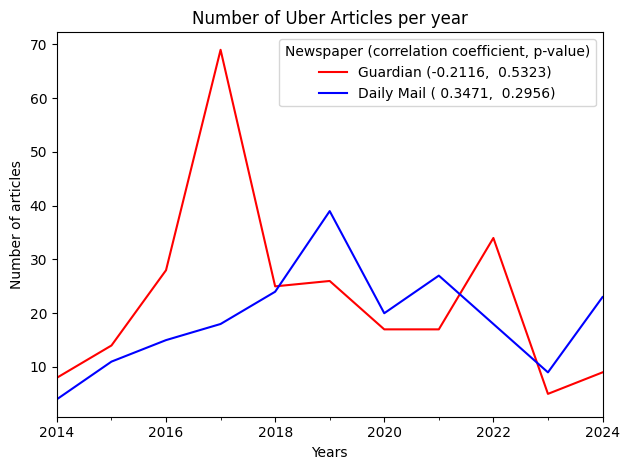

In [87]:
# This creates the plot that shows number of uber articles by month

# 1. get the data
obj_old = {}
obj = []
with open('./final_data.json', encoding='utf-8') as f:
    obj_old = json.load(f)

resolution = 1

def get_frequency_df(obj, resolution):

    # What I need is a df of form PAPER/MONTH(everymonth)/COUNT(set0)
    # Need to now earliest month and year and latest month and year (use published)
    # Sort obj by published - do it with data frame

    #df_grouped.plot('monthpub', 'count')
    df = pd.DataFrame.from_records(obj).sort_values('published')
    # Get first timestamps
    first = (df.iloc[0]['published'])
    print(first)
    first = datetime.fromtimestamp(first)

    # ignore 2025
    all_years = [y for y in range(int(first.year), 2024 + 1)]
    all_months = [str(y) + "-" + ("0" if m < 10 else "") + str(m) + "-01" for m in range(1,13) for y in range(first.year, 2025 + 1)]

    # df2 is used only for the time plot

    df2dict = {
        m : {
            'guardian': 0,
            'dailymail': 0
        } for m in all_months
    }

    df2 = pd.DataFrame.from_records(df2dict).transpose()

    def month_function(m):
        return round(((m - 1)//(12/resolution)) * (12/resolution) + 1)

    # months that are possible given resolution
    possible_months = set([month_function(x) for x in range(1,13)])

    print(possible_months)

    # Loop through df
    for index, row in df.iterrows():
        # Convert time to first of given month/year
        month = datetime.fromtimestamp(row['published'])
        # rounded month
        m = month_function(month.month)
        month = month.strftime('%Y-' + ("0" if m < 10 else "") + str(m) + '-01')
        paper = row['paper']
        #month = "2025-01-01"
        # update df2 accordingly
        df2.loc[month, paper] += 1

    #df2.loc[(df2['paper'] == 'guardian') & (df2['month'] == "2025-01-01"), 'count'] = 24

    # convert index to datetime
    df2.index = pd.to_datetime(df2.index)


    # drop months that haven't happened
    # let's ignore 2025 because it hasn't been a full years
    df2= df2[(df2.index.year != 2025)]

    #this step is for accounting for month resolution
    df2 = df2[df2.index.month.isin(possible_months)]
    return df2

df2 = get_frequency_df(obj_old, 1)

plt.figure(figsize=(20, 2), dpi=150)
df2.plot(label="Paper", color=['red', 'blue'])

plt.title('Number of Uber Articles per year')
plt.xlabel('Years')
plt.ylabel("Number of articles")

# get the correlation between year published and number of articles for each paper
dm_c, dm_p = stats.pearsonr(df2.index.year, df2['dailymail'])
g_c, g_p = stats.pearsonr(df2.index.year, df2['guardian'])

plt.legend([f'Guardian ({g_c : .4f}, {g_p : .4f})', f'Daily Mail ({dm_c : .4f}, {dm_p : .4f})']).set_title('Newspaper (correlation coefficient, p-value)')
# adding legend.
plt.tight_layout()
plt.show()

In [124]:
get_sentiment("uber is a ride sharing app")

0.4703

1390712901
{1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12}


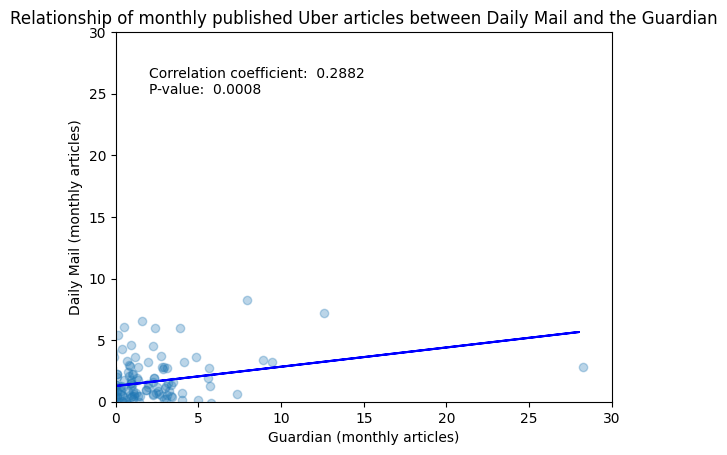

In [115]:
# this for checking if there's any correlation between how many articles daily mail publish and guardian do each month
df_corr = get_frequency_df(obj_old, 12)

# plot scatter plot of guardian and dailymail
import random

# add random jitter to make better visualisation
plt.scatter(df_corr['guardian'].apply(lambda x : x + random.random() - 0.5), df_corr['dailymail'].apply(lambda x : x + random.random() - 0.5), alpha=0.3)

"""if plt.gca().get_xlim() > plt.gca().get_ylim():
  plt.ylim(plt.gca().get_xlim())
else:
  plt.xlim(plt.gca().get_ylim())"""
gca = plt.gca()
xlim = math.ceil(gca.get_xlim()[1])
ylim = math.ceil(gca.get_ylim()[1])
bigger = xlim
if xlim > ylim: bigger = xlim
elif ylim > xlim: bigger = ylim
else: bigger = xlim
plt.xlim(0, bigger)
plt.ylim(0, bigger)

# Calculate the correlation coefficient and p-value
correlation_coefficient, p_value = stats.pearsonr(df_corr['guardian'], df_corr['dailymail'])

#plot line of best fit
m, b = np.polyfit(df_corr['guardian'], df_corr['dailymail'], 1)
plt.plot(df_corr['guardian'], m*df_corr['guardian'] + b, color='blue')


# Display the results on the graph
plt.text(2, 25, f'Correlation coefficient: {correlation_coefficient : .4f} \nP-value: {p_value : .4f}')
plt.title("Relationship of monthly published Uber articles between Daily Mail and the Guardian")
plt.xlabel("Guardian (monthly articles)")
plt.ylabel("Daily Mail (monthly articles)")

plt.show()



In [ ]:
# Remove duplicates in the dataset
loc = "./merged.json"

# check for dupe headlines

obj = []
with open('./data/merged.json', encoding='utf-8') as f:
    obj = json.load(f)

headlines = {
    'guardian': set([]),
    'dailymail': set([])
}

# Loop through articles
n = 0
new_obj = {'guardian' : [], 'dailymail' : []}

for paper in ['guardian', 'dailymail']:
    for article in obj[paper]:
        headline = article['headline'].strip()
        if(headline in headlines[paper]):
            print("DUPE: " + headline)
            n += 1
        else:
            headlines[paper].add(headline)
            new_obj[paper].append(article)

print(n)

with open('./data/merged_nodupe1.json', 'w') as f:
  json.dump(new_obj, f)

In [ ]:
# gonna check for dupes by making dictionary of all authors (and list of authors), and making sure no two similar articles show

obj = []
with open('./data/merged_nodupe1.json', encoding='utf-8') as f:
    obj = json.load(f)

authors_dict = {}

for paper in ['guardian', 'dailymail']:
    for article in obj[paper]:
        index = str([a.strip() for a in article['authors']])
        headline = article['headline'].strip()
        if index not in authors_dict: authors_dict[index] = [headline]
        else: authors_dict[index].append(headline)

# we're only interested in duplicates so remove all authors with multiple entries


n = 0
new_obj = {}

for key in authors_dict.keys():
    if len(authors_dict[key]) < 2:
        n += 1
    else:
        new_obj[key] = authors_dict[key]

print("removed " + str(n) + " authors")

# store remaining authors in file for inspection


with open('./data/dupe_authors.json', 'w') as f:
  json.dump(new_obj, f)



removed 231 authors


In [ ]:
# Install scikit
%pip install nltk scikit-learn

Note: you may need to restart the kernel to use updated packages.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

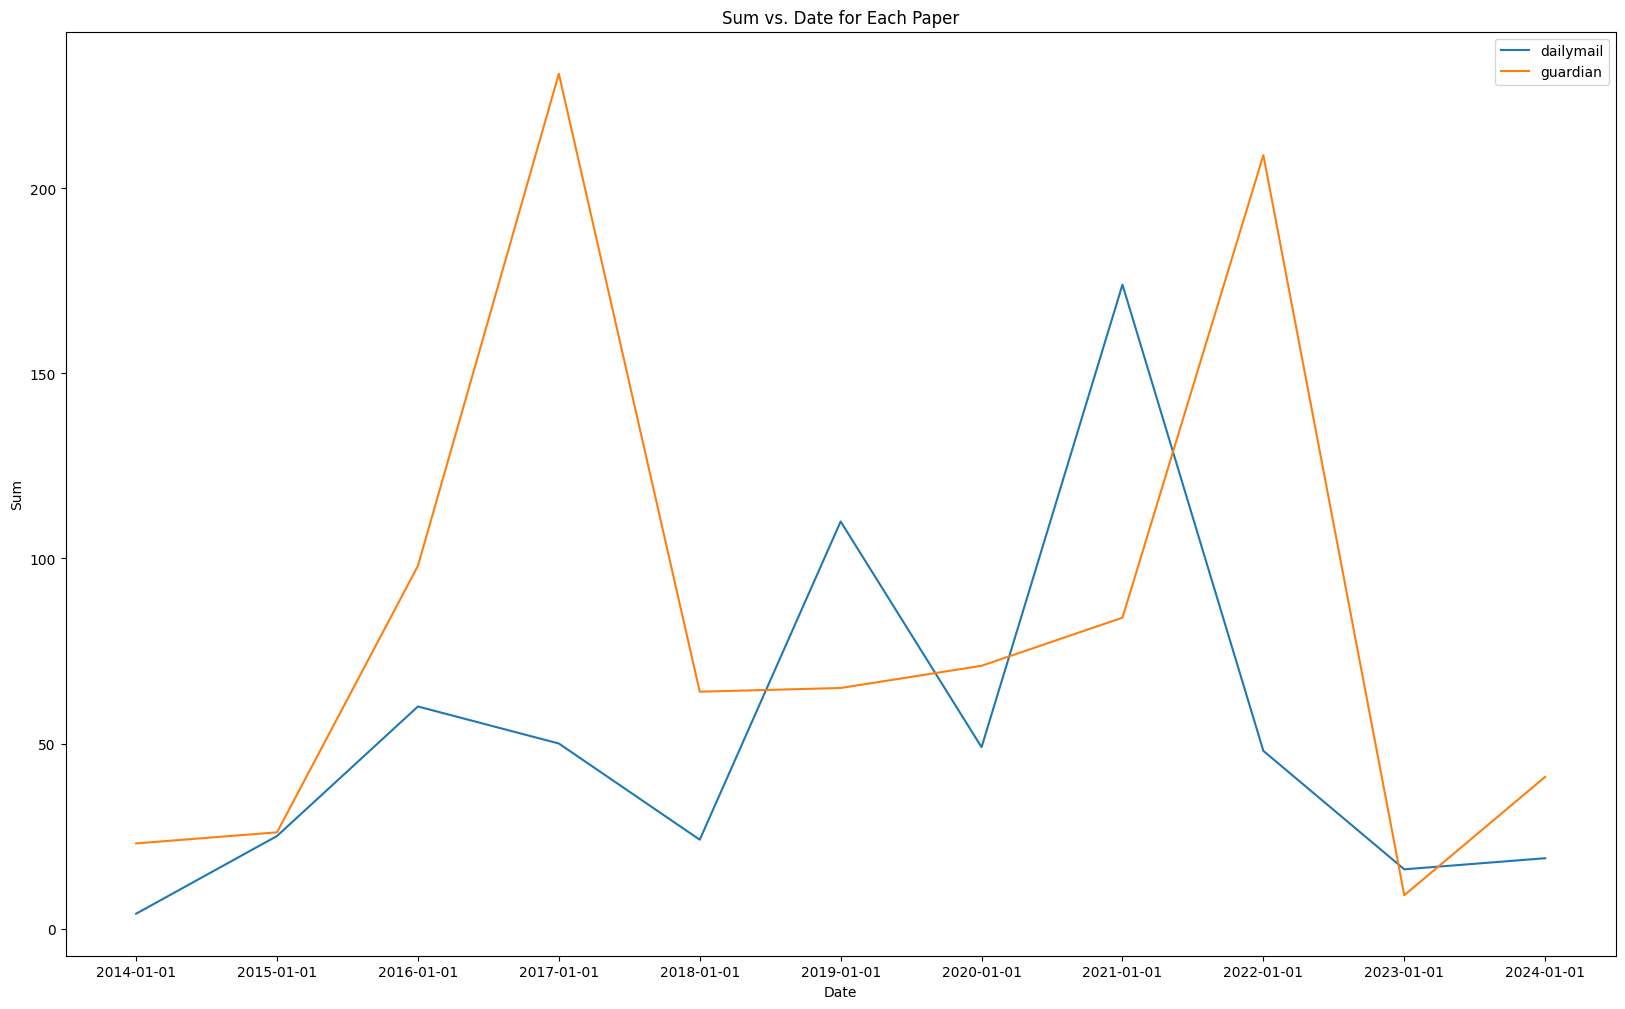

190951
204868


<ipython-input-8-29164367b36c>:259: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '320.79188901864876' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_overall.at['expected', k] = (df_overall.loc['dailymail'][k] * proportion)
<ipython-input-8-29164367b36c>:259: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '22.530534011343224' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_overall.at['expected', k] = (df_overall.loc['dailymail'][k] * proportion)
<ipython-input-8-29164367b36c>:259: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '38.6237725908741' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_overall.at['expected', 

<Axes: >

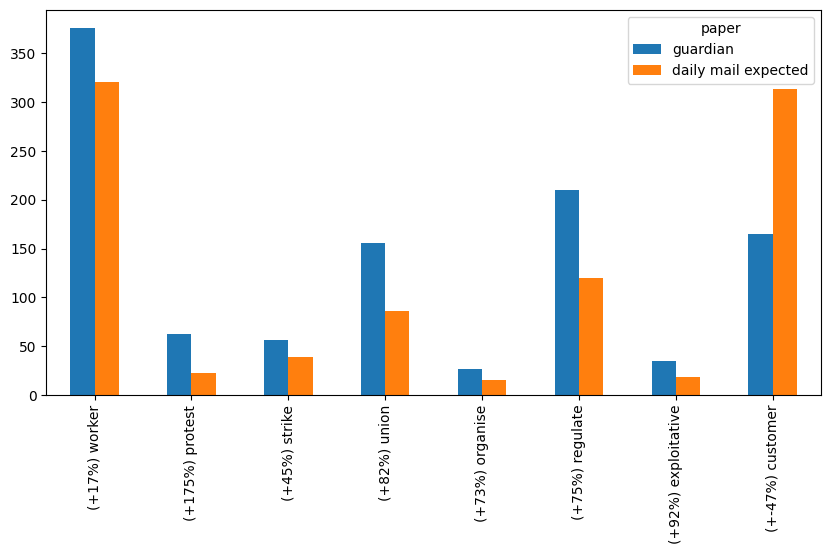

In [8]:
# sentiment analysis of daily mail and uber
# do separately by headline and content
# First exercise - count most frequent words of each article
import json
# Let's try headline first
# First we load the data

df = load_articles('./final_data.json')

def most_frequent_words(text):
    words = word_tokenize(text.lower())
    stop_words = set(stopwords.words('english'))
    stemmer = PorterStemmer()
    filtered_words = [stemmer.stem(word) for word in words if word.isalnum() and word not in stop_words]
    filtered_word_counts = Counter(filtered_words)
    return filtered_word_counts.most_common()

# remove all words with compound sentiment between +/-neut (exclusive)
# sentiment dict just to save compute
sent_dict = {}
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    # add single words to sent_dict
    if " " not in text:
      if text not in sent_dict:
          sent_dict[text] = sia.polarity_scores(text)['compound']
      return sent_dict[text]
    else:
        sent_dict[text] = sia.polarity_scores(text)['compound']
        return sent_dict[text]


# Reveals the most important words in an article given
# The frequency of these words in general
def tf_idf_scores(text, neut=0):
    documents = [text]
    vectorizer = TfidfVectorizer(stop_words='english')
    tfidf_matrix = vectorizer.fit_transform(documents)
    feature_names = vectorizer.get_feature_names_out()
    tfidf_scores = tfidf_matrix.toarray()[0]
    tfidf_dict = dict(zip(feature_names, tfidf_scores))
    tfidf_dict = dict(sorted(tfidf_dict.items(), key=lambda item: item[1], reverse=True))
    # Remove entries that include numbers because these rarely indicate anything
    for key in list(tfidf_dict.keys()):
        if any(char.isdigit() for char in key) or get_sentiment(key) < neut and get_sentiment(key) > -neut:
            del tfidf_dict[key]
    return tfidf_dict


def collapse_df_dates(df, m_res, y_res = 1):
    # remove 2025 dates because incomplete
    df = df.copy()[df['published'] < 1735689600]
    def month_function(m):
        return round(((m - 1)//(12/m_res)) * (12/m_res) + 1)

    first_year = df['published'].min()
    first_year = datetime.fromtimestamp(first_year)
    first_year = first_year.year

    def year_function(y):
      x = y - first_year
      return (int(math.floor(x / y_res)) * y_res) + first_year

    def date_function(timestamp):
        d = datetime.fromtimestamp(timestamp)
        m = month_function(d.month)
        d = d.replace(month=m, day=1)
        if not y_res == 1: y = year_function(d.year)
        else: y = d.year
        d = d.replace(year=y)
        month = d.strftime('%Y-%m-%d')
        return month

    df['published'] = df['published'].apply(date_function)
    return df

def collapse_df(df, m_res, y_res):
    df = collapse_df_dates(df, m_res, y_res)

    df2 = pd.DataFrame.from_dict({
        "published" : df['published'].unique()
    })
    def concat_headlines(pub):
        x = "\n".join(df[df['published'] == pub]['headline'])
        return x
    def concat_bodies(pub):
        x = "\n".join(df[df['published'] == pub]['body'])
        return x

    df2['headlines'] = df2['published'].apply(concat_headlines)
    df2['bodies'] = df2['published'].apply(concat_bodies)

    # sort by date
    df2 = df2.sort_values(by=['published'])
    df2.set_index('published', inplace=True)
    """df2 = df2.transpose()
    df2 = df2.map(str)"""

    # add missing dates
    first = (df2.index[0])
    first = datetime.strptime(first, '%Y-%m-%d')
    # ignore 2025
    all_years = [y for y in range(int(first.year), 2024 + 1)]
    all_months = [str(y) + "-" + ("0" if (m * (12/m_res) + 1) < 10 else "") + str(int(m * (12/m_res) + 1)) + "-01" for m in range(0,m_res) for y in range(first.year, 2024 + 1)]

    # add month with blank headlines and bodies if not in df
    for month in all_months:
        if month not in df2.index:
          # add row to df
          df2.loc[month] = [""] * len(df2.columns)

    # do tf_idf_scores
    return df2

# could use topic modelling

def df_idf_table(df, top_n, neut = 0):
  df2 = df.copy()

  df2['headlines_tf'] = df['headlines'].apply(tf_idf_scores, neut=neut)
  df2['bodies_tf'] = df['bodies'].apply(tf_idf_scores, neut=neut)
  for i in range(0, top_n):
    df2['h' + str(i)] = df2['headlines_tf'].apply(lambda x: list(x.keys())[i] if i < len(x) else "")
    df2['b' + str(i)] = df2['bodies_tf'].apply(lambda x: list(x.keys())[i] if i < len(x) else "")
  df2.drop(columns=['headlines_tf', 'bodies_tf', 'headlines', 'bodies'], inplace=True)
  # sort by date
  df2 = df2.sort_values(by=['published'])
  print(df2.columns)
  df2.set_index('published', inplace=True)
  print("BELLO")
  df2 = df2.transpose()
  df2 = df2.map(str)
  return df2

def heatmap_df(df, m_res = 1, y_res = 1, top_n = 10, neut = 0, paper = None):
  if paper != None:
    df = df.copy()[df['paper'] == paper]
  df = collapse_df(df, m_res, y_res)
  df = df_idf_table(df, 10, neut=0.2)
  df_vals = df.copy().map(get_sentiment)
  fig, ax = plt.subplots(figsize=(20,10))
  sns.heatmap(df_vals, annot=df, fmt="", cmap="icefire_r", vmin=-1, vmax=1)
  plt.show()

def get_topics_text(text):
  vectorizer = TfidfVectorizer(stop_words='english', max_df=.95, min_df=.05)
  article_body_transformed= vectorizer.fit_transform(sent_tokenize(text))
  lda = LatentDirichletAllocation(n_components=5, random_state=42)
  lda.fit(article_body_transformed)
  feature_names = vectorizer.get_feature_names_out()
  for topic_idx, topic in enumerate(lda.components_):
      print(f"Topic {topic_idx}:")
      print(" ".join([feature_names[i] for i in topic.argsort()[:-10 - 1:-1]]))

#heatmap_df(df, 1, 1, 10, 0.2)

# next try topic modelling
# filter by newspaper
# maybe compute a value which takes into account importance AND sentiment
# make a scatter plot for each paper that plots importance of word (from topic modelling) with sentiment
# i think concat(str) THEN TOPIC MODELLING risks prioritising lowest common denominator words
# e.g. suppose strike is in 50% but DRIVER, UBER are in 100%, then it's gonna be kind of dead
# therefore, collapse after doing the analysis

"""
df_tf = collapse_df(df, 1, y_res=5000)
df_tf['headlines_tf'] = df_tf['headlines'].apply(tf_idf_scores, neut=0)
df_tf['bodies_tf'] = df_tf['bodies'].apply(tf_idf_scores, neut=0)
get_topics_text(df_tf['bodies'][4])
df_tf.head()
"""
import re
def match_word(text, pattern):
  pattern = rf'\b{pattern}\b'
  matches = re.findall(pattern, text)
  return len(matches)


def match_words(df, patterns_dict, ignore = ["customer"]):
  for pattern in patterns_dict:
    # ignore if word included in columns
    if pattern in df.columns:
      continue
    # Count occurrences of word in bodies preceded and followed by punctuation or space
    # make a pattern of word followed and preceded by punctuation
    df[pattern] = df['bodies'].apply(lambda x : match_word(x, patterns_dict[pattern]))
  df['sum'] = 0
  for pattern in patterns_dict:
    if pattern not in ignore:
      df['sum'] += df[pattern]

  return df

keyword_regexes = {
    'worker' : r'workers?',
    'protest': r'protest(er|ers|ing|ed)?',
    'strike': r'strik(er|es|ers|ing|e)',
    'union' : r'union(ise|s|isation|ising|ised|ize|ization|ized|izing)?',
    'organise' : r'organ(ise|ising|isers|ised|ises|ize|izing|izers|ized)',
    'regulate' : r'regulat(ion|e|ing|or|ions|es|ed|ors)',
    'exploitative' : r'exploit(ative|ing|ed)?',
    'customer' : r'customer(s)?',
}

def create_df_matched(df, keyword_regexes, m_res):
    # do guardian and daily mail separately
    dfg = collapse_df(df[df['paper'] == 'guardian'], m_res, y_res=1)
    dfm = collapse_df(df[df['paper'] == 'dailymail'], m_res, y_res=1)

    dfg = match_words(dfg, keyword_regexes)
    dfm = match_words(dfm, keyword_regexes)

    # concat
    dfg['paper'] = 'guardian'
    dfm['paper'] = 'dailymail'
    df_matched = pd.concat([dfg, dfm])
    df_matched = df_matched.sort_values(by=['published'])
    return df_matched

df_matched = create_df_matched(df, keyword_regexes, 1)
# Create a figure and axes
fig, ax = plt.subplots(figsize=(20, 12))  # Adjust figsize as needed

# Group the dataframe by 'paper' and plot 'sum' against 'published'
for paper, group in df_matched.groupby('paper'):
    ax.plot(group.index, group['sum'], label=paper)

# Set plot title and labels
ax.set_title('Sum vs. Date for Each Paper')
ax.set_xlabel('Date')
ax.set_ylabel('Sum')

# Add a legend
ax.legend()

# Display the plot
plt.show()

df_overall = df_matched.groupby('paper').sum()
# add expected row
df_overall.loc['expected'] = df_overall.loc['dailymail']
# expected row is just how many instances guardian should have if same proportion to daily mail
# i.e. multiply dailymail by how many more words the guardian has (bodies)

dm_words = len(df_overall.loc['dailymail']['bodies'].split())
g_words = len(df_overall.loc['guardian']['bodies'].split())

# add other column
df_overall['other'] = df_overall['bodies'].apply(str.split).apply(len) - df_overall['sum']

print(dm_words)
print(g_words)
proportion = g_words / dm_words
# drop bodies and headlines columns
df_overall.drop(columns=['headlines', 'bodies'], inplace=True)
keyword_regexes['other'] = ""
for k in keyword_regexes:
  df_overall.at['expected', k] = (df_overall.loc['dailymail'][k] * proportion)
# drop other key from keyword_regexes
keyword_regexes.pop('other')

# run a bar chart showing expected vs guardian
df_overall.drop(columns=['sum'], inplace=True)
df_overall = df_overall.transpose()
df_overall.drop(columns=['dailymail'], inplace=True)
#rename expected column name
df_overall.rename(columns={'expected': 'daily mail expected'}, inplace=True)
# rename all indexes - add percentage increase

# loop through rows
df_overall_plot = df_overall.copy()
df_overall_plot = df_overall_plot.drop("other")
df_overall_plot.index = "(+" + (round(-100 + 100 * df_overall_plot['guardian'] / df_overall_plot['daily mail expected'])).apply(int).astype(str) + "%) " + df_overall_plot.index
df_overall_plot.plot(kind='bar', figsize=(10, 5))




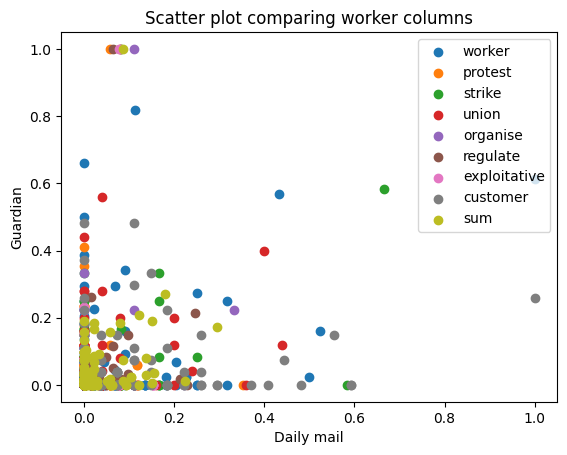

Correlation coefficients and p values (< 0.01)
worker: 0.36720247061211403 1.4843465482916265e-05  True
protest: 0.08522260796370248 0.3312548362126512  False
strike: 0.3862607861401288 4.775647458727573e-06  True
union: 0.24092992264455856 0.005388159725748435  True
organise: 0.3013525806953922 0.00044585481486219956  True
regulate: 0.24329505597387624 0.004938348946968703  True
exploitative: 0.12775455063879998 0.14434052386028084  False
customer: 0.11945388697285055 0.17248654107570066  False
sum: 0.2893941800619805 0.0007638364657199941  True


In [ ]:
# use matched_df to look at correlation of words in months between papers
df = load_articles('./final_data.json')
df_matched_corr = create_df_matched(df, keyword_regexes, 12)

# normalise to 1 for all keyword columns
ls = list(keyword_regexes.keys())
ls.append('sum')

for k in ls:
  df_matched_corr[k] = df_matched_corr[k] / df_matched_corr[k].max()


# get correlation of 'worker'
df_dm = df_matched_corr[df_matched_corr['paper'] == 'dailymail']
df_g = df_matched_corr[df_matched_corr['paper'] == 'guardian']


# create scatter plot comparing their worker columns
for k in ls:
  plt.scatter(x = df_dm[k], y = df_g[k], label=k)
plt.xlabel('Daily mail')
plt.ylabel('Guardian')
plt.title('Scatter plot comparing worker columns')
plt.legend()
# set xlim and ylim as equal
gca = plt.gca()
xlim = math.ceil(gca.get_xlim()[1])
ylim = math.ceil(gca.get_ylim()[1])
if xlim > ylim: gca.set_ylim(0, xlim)
elif ylim > xlim: gca.set_xlim(0, ylim)


plt.show()
# print correlation coefficients for each keyword with p value
print('Correlation coefficients and p values (< 0.01)')

# put this in a table
for k in ls:
  c, p = stats.pearsonr(df_dm[k], df_g[k])
  print(k + ": " + str(c) + " " + str(p) + "  " + str(p < 0.01))


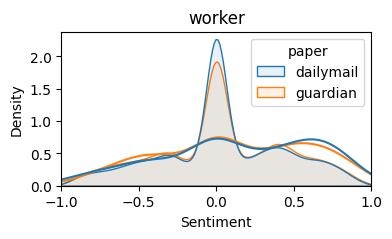

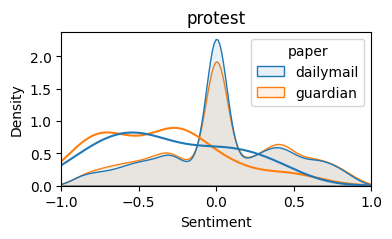

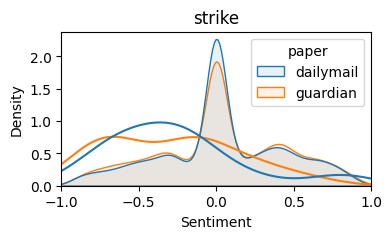

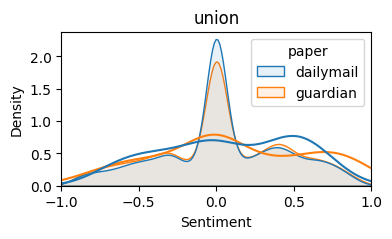

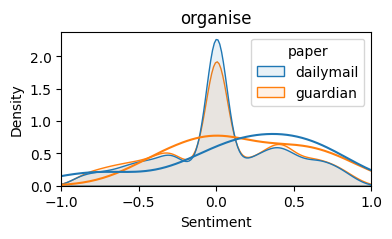

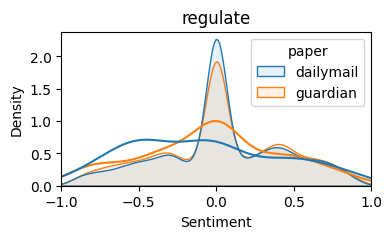

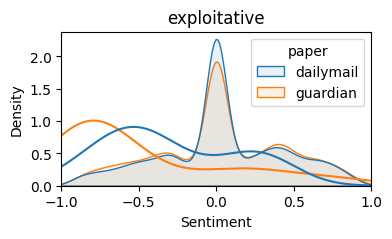

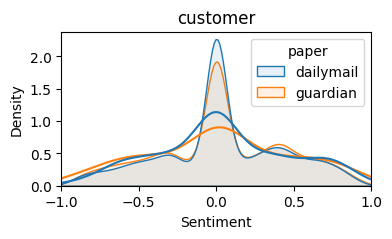

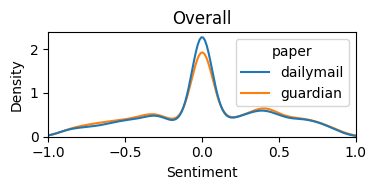

Daily mail: 8530 guardian: 8014


,paper,sentence,worker,protest,strike,union,organise,regulate,exploitative,customer,sentiment
475,dailymail,i think it can happen to anyone and you just n...,False,False,False,False,False,False,False,False,0.0000
1306,dailymail,"during the summit, uber execs also revealed th...",False,False,False,False,False,False,False,False,0.0772
1010,dailymail,the ruling means drivers involved in the tribu...,False,False,False,False,False,False,False,False,0.2960
14435,guardian,taylor explained that dependent contractors sh...,False,False,False,False,False,False,False,False,-0.5719
1941,dailymail,"i'm like, ""oh no, it's a work account so it ne...",False,False,False,False,False,False,False,False,0.0772
7245,dailymail,lyft is the latest ride-sharing app to face in...,False,False,False,False,False,False,False,True,-0.5994
416,dailymail,"however, the report also found the rising cost...",False,False,False,False,False,False,False,False,0.0000
4474,dailymail,many are now believed to be working for takeaw...,False,False,False,False,False,False,False,False,0.0000
7114,dailymail,"then i figured out an exit strategy: uber,' he...",False,False,False,False,False,False,False,False,0.0000
8505,dailymail,the taxi company's licence was revoked in lond...,False,False,False,False,False,False,False,False,-0.8261


In [ ]:
# this is going to do topic modelling for each sentence that includes keywords
# first step is to combine all bodies into a single block of text
df = load_articles('./final_data.json')
df.head(5)

# merge all bodies of each paper into list of sentences
body_dm = sent_tokenize(". ".join(df[df['paper'] == 'dailymail']['body']))
body_g = sent_tokenize(". ".join(df[df['paper'] == 'guardian']['body']))

"""import string
#get headlines as np array
def remove_punctuation(text):
   # Create a translation table to remove punctuation
   translator = str.maketrans('', '', string.punctuation)
   # Apply the translation table to the text
   return text.translate(translator)

# strip punctuation before tokenising so that number of headlines = number of sentences
body_dm = sent_tokenize(". ".join(df[df['paper'] == 'dailymail']['headline'].apply(remove_punctuation)))
body_g = sent_tokenize(". ".join(df[df['paper'] == 'guardian']['headline'].apply(remove_punctuation)))"""

all_sents = body_dm + body_g

# two lists of sentences
# keep only sentences that include the keywords
"""body_dm = [s for s in body_dm if any(match_word(s, keyword) for keyword in keyword_regexes.values())]
body_g = [s for s in body_g if any(match_word(s, keyword) for keyword in keyword_regexes.values())]"""

#for s in body_dm: print(s)

# let's make a dataframe
# PAPER | SENTENCE | keywords (t/f) | SENTIMENT | 5 TOPICS
df_sent = pd.DataFrame(columns=['paper', 'sentence'])
df_sent['paper'] = ['dailymail'] * len(body_dm) + ['guardian'] * len(body_g)
df_sent['sentence'] = body_dm + body_g


for k in keyword_regexes:
    df_sent[k] = df_sent['sentence'].apply(lambda x : match_word(x, keyword_regexes[k]) > 0)

df_sent['sentiment'] = df_sent['sentence'].apply(get_sentiment)
# topic model
#df_sent['topics'] = df_sent['sentence'].apply(get_topics_text)

# create plot

# create sentiment kde
for k in keyword_regexes:
  if df_sent[k].any():
    sns.kdeplot(data=df_sent[df_sent[k] == True], x="sentiment", hue='paper', fill=False, common_norm=False)
    sns.kdeplot(data=df_sent, x="sentiment", hue='paper', fill=True, common_norm=False, alpha = 0.1)
    plt.title(k)
    plt.xlim(-1, 1)
    # make graphs small size
    plt.gcf().set_size_inches(4, 2)
    plt.xlabel('Sentiment')
    plt.ylabel('Density')
    plt.show()

# also do overall
sns.kdeplot(data=df_sent, x="sentiment", hue='paper', fill=False, common_norm=False)
plt.title("Overall")
plt.xlim(-1, 1)
plt.gcf().set_size_inches(4, 2)
plt.xlabel('Sentiment')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

# add keywords as labels
#plt.legend(labels=keyword_regexes.keys())
# print how many sentences are daily mail and how many are guardian
print("Daily mail: " + str(len(body_dm)) + " guardian: " + str(len(body_g)))

# conclude here that sentiment analysis doesn't tell us much
# e.g., we expect both papers to portray strikes badly
# the difference is that guardian might focus more on worker-oriented stuff whereas
# daily mail will look more at delays (consumer-facing issues)

df_sent.sample(10)

<ipython-input-62-c73a966d6b29>:59: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(label, (words_df['sentiment'][i], words_df['frequency'][i]))


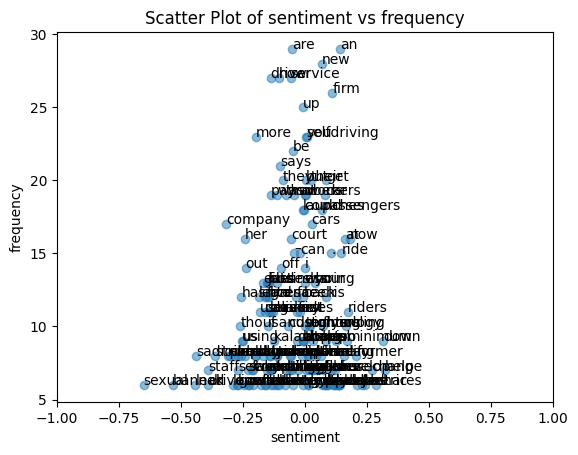

,frequency,sentiment
word,,
sexual,6,-0.650217
banned,6,-0.530883
leak,6,-0.441483
sadiq,8,-0.438475
staff,7,-0.390371
drive,6,-0.38965
strike,8,-0.3623
company,17,-0.318518
employees,8,-0.30905


In [ ]:



import string
#get headlines as np array
def remove_punctuation(text):
   # Create a translation table to remove punctuation
   translator = str.maketrans('', '', string.punctuation)
   # Apply the translation table to the text
   return text.translate(translator)

# strip punctuation before tokenising so that number of headlines = number of sentences
body_dm = sent_tokenize(". ".join(df[df['paper'] == 'dailymail']['headline'].apply(remove_punctuation)))
body_g = sent_tokenize(". ".join(df[df['paper'] == 'guardian']['headline'].apply(remove_punctuation)))

all_sents = body_dm + body_g

#for s in body_dm: print(s)

# let's make a dataframe - all headlines without punctuation
# PAPER | SENTENCE | keywords (t/f) | SENTIMENT | 5 TOPICS
df_sent = pd.DataFrame(columns=['paper', 'headline'])
df_sent['paper'] = ['dailymail'] * len(body_dm) + ['guardian'] * len(body_g)
df_sent['headline'] = body_dm + body_g
df_sent['sentiment'] = df_sent['headline'].apply(get_sentiment)

"""# plot sentiment on one dimensional scatter plot
plt.scatter(df_sent['sentiment'], [0] * len(df_sent), alpha=0.5)
plt.xlabel('sentiment')
plt.xlim(-1, 1)
plt.yticks([])  # Remove y-axis ticks
plt.title('1D Scatter Plot of sentiment')
plt.show()"""

# let's plot frequency by sentiment of each word
df_sent.sample(5)

import numpy as np
words_df = pd.DataFrame(columns=['word', 'frequency', 'sentiment'])
words_df.set_index('word', inplace=True)

for headline, sentiment in zip(df_sent['headline'], df_sent['sentiment']):
  for word in headline.split():
    if word in words_df.index:
      words_df.loc[word, 'frequency'] += 1
      words_df.loc[word, 'sentiment'] += sentiment
    else:
      words_df.loc[word, 'frequency'] = 1
      words_df.loc[word, 'sentiment'] = sentiment

words_df['sentiment'] = words_df['sentiment'] / words_df['frequency']
words_df.sort_values(by=['frequency'], ascending=False, inplace=True)
words_df.head(10)
# remove frequency over 100
words_df = words_df[words_df['frequency'] < 30]
# remove frequency under 10
words_df = words_df[words_df['frequency'] > 5]

# scatter plot of sentiment vs frequency
plt.scatter(words_df['sentiment'], words_df['frequency'], alpha=0.5)
for i, label in enumerate(words_df.index):
  plt.annotate(label, (words_df['sentiment'][i], words_df['frequency'][i]))

plt.xlabel('sentiment')
plt.ylabel('frequency')
plt.xlim(-1, 1)
plt.title('Scatter Plot of sentiment vs frequency')
plt.show()

# sort by sentiment
words_df.sort_values(by=['sentiment'], ascending=True, inplace=True)
words_df.head(10)



In [9]:
# This block will plot sentiment of a headline against body
df = load_articles('./final_data.json')
# preserve published, body, headline (index)
df = df[['published', 'paper', 'headline', 'body']]

# get sentiments of headline and body
df['headline_sentiment'] = df['headline'].apply(get_sentiment)
df['body_sentiment'] = df['body'].apply(get_sentiment)





Goodness of fit for guardian: PearsonRResult(statistic=np.float64(0.30574368699922294), pvalue=np.float64(7.482431750779247e-07))
Pearson test coefficient for guardian: PearsonRResult(statistic=np.float64(0.30574368699922294), pvalue=np.float64(7.482431750779247e-07))
Goodness of fit for dailymail: PearsonRResult(statistic=np.float64(0.2977268094593343), pvalue=np.float64(1.257034890266777e-05))
Pearson test coefficient for dailymail: PearsonRResult(statistic=np.float64(0.2977268094593343), pvalue=np.float64(1.257034890266777e-05))


<ipython-input-111-b924c2135ee3>:15: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(df_slice['headline_sentiment'], pol(df_slice['headline_sentiment']), "r--", color=c)


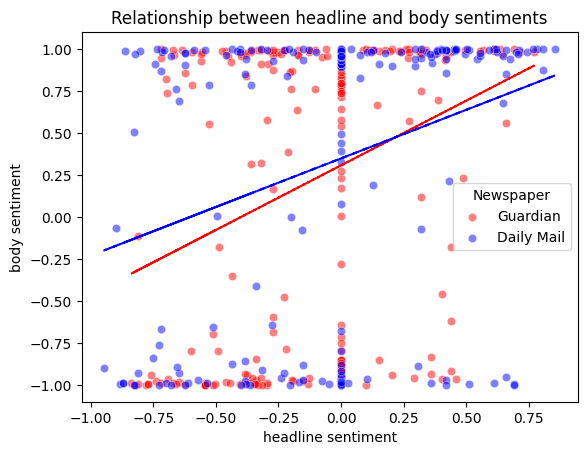

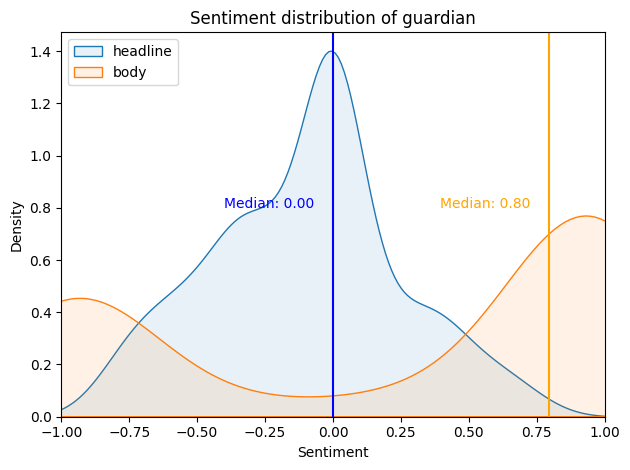

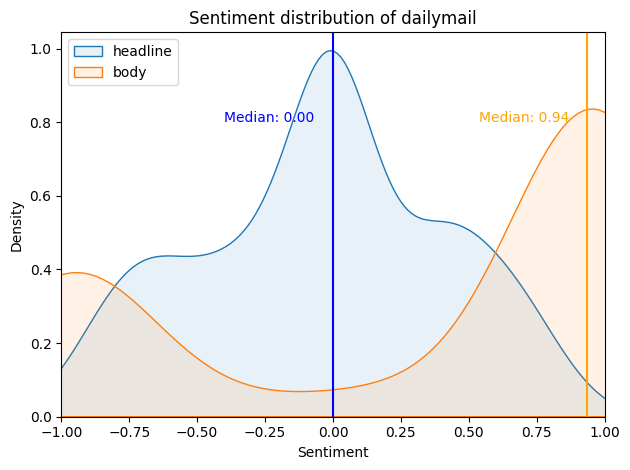

In [111]:
# plot sentiment of headline against body for each news paper
for p, c in zip(['guardian', 'dailymail'], ['red', 'blue']):
  df_slice = df[df['paper'] == p]
  sns.scatterplot(data=df[df['paper'] == p], x="headline_sentiment", y="body_sentiment", alpha = 0.5, color=c)

# add lines of best fit
for p, c in zip(['guardian', 'dailymail'], ['red', 'blue']):
  df_slice = df[df['paper'] == p]
  z = np.polyfit(df_slice['headline_sentiment'], df_slice['body_sentiment'], 1)
  pol = np.poly1d(z)
  # print goodness of fit
  print(f'Goodness of fit for {p}: {stats.pearsonr(df_slice["headline_sentiment"], df_slice["body_sentiment"])}')
  # print pearson test coefficient and p-value
  print(f'Pearson test coefficient for {p}: {stats.pearsonr(df_slice["headline_sentiment"], df_slice["body_sentiment"])}')
  plt.plot(df_slice['headline_sentiment'], pol(df_slice['headline_sentiment']), "r--", color=c)

plt.title(f'Relationship between headline and body sentiments')
# set colours as red and blue
plt.legend(['Guardian', 'Daily Mail']).set_title('Newspaper')
plt.xlabel('headline sentiment')
plt.ylabel('body sentiment')


plt.show()

# do a kde of body and headline
for p in ['guardian', 'dailymail']:
  sns.kdeplot(data=df[df['paper'] == p], x="headline_sentiment", fill=True, common_norm=False, alpha = 0.1)
  sns.kdeplot(data=df[df['paper'] == p], x="body_sentiment", fill=True, common_norm=False, alpha = 0.1)
  # get median sentiments

  median_headline_sentiment = df[df['paper'] == p]['headline_sentiment'].median()
  median_body_sentiment = df[df['paper'] == p]['body_sentiment'].median()
  plt.axvline(median_headline_sentiment, color='blue', linestyle='-')
  plt.axvline(median_body_sentiment, color='orange', linestyle='-')
  plt.text(median_headline_sentiment - 0.4, 0.8, f'Median: {median_headline_sentiment:.2f}', color='blue')  # Text annotation
  plt.text(median_body_sentiment - 0.4, 0.8, f'Median: {median_body_sentiment:.2f}', color='orange')  # Text annotation

  plt.title(f'Sentiment distribution of {p}')
  plt.xlim(-1, 1)
  plt.xlabel('Sentiment')
  plt.ylabel('Density')
  # add legend for headline and body
  plt.legend(labels=['headline', 'body'])
  plt.tight_layout()
  plt.show()

# get pearson coefficient overall

In [ ]:
# sort by body sentiment
# this shows the articles with biggest difference between headline and body sentiment
df["sent_diff"] = abs(df['headline_sentiment'] - df['body_sentiment'])
df.sort_values(by=['sent_diff'], ascending=False, inplace=True)
df.head(5)

,published,paper,headline,body,headline_sentiment,body_sentiment,sent_diff
312,1574761116,dailymail,man with criminal caution for child porn image...,a driver who received a caution for distributi...,-0.8625,0.9893,1.8518
253,1732802225,dailymail,uber launches teen accounts - but concerned us...,uber has been slammed across social media over...,-0.8047,0.9882,1.7929
367,1658027404,dailymail,warning for travellers heading overseas to soa...,"a man paid more than $1,300 for an uber from p...",-0.8225,0.9683,1.7908
357,1644918263,dailymail,uber passengers could face paying up to 20% mo...,uber passengers in london face a 20 per cent r...,-0.7351,0.9993,1.7344
227,1401490740,guardian,will uber kill the black cab?,black cabs – long a quintessential feature of ...,-0.7178,0.9977,1.7155


<ipython-input-140-006d09899d50>:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([df[df['paper'] == 'guardian']['headline_sentiment'], df[df['paper'] == 'dailymail']['headline_sentiment']], labels=['Guardian', 'Daily Mail'])


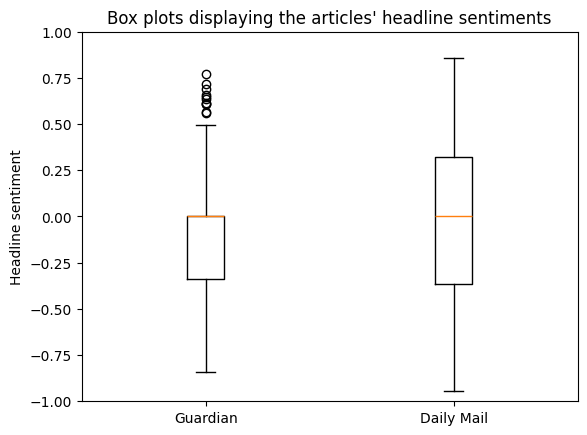

<ipython-input-140-006d09899d50>:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([df[df['paper'] == 'guardian']['headline_sentiment_squared'], df[df['paper'] == 'dailymail']['headline_sentiment_squared']], labels=['Guardian', 'Daily Mail'])


count    252.000000
mean      -0.101787
std        0.347217
min       -0.840200
25%       -0.340000
50%        0.000000
75%        0.000000
max        0.771300
Name: headline_sentiment, dtype: float64
count    208.000000
mean      -0.033834
std        0.446341
min       -0.945800
25%       -0.366900
50%        0.000000
75%        0.323650
max        0.855500
Name: headline_sentiment, dtype: float64
TtestResult(statistic=np.float64(-1.8358758682182024), pvalue=np.float64(0.03351205672492258), df=np.float64(458.0))


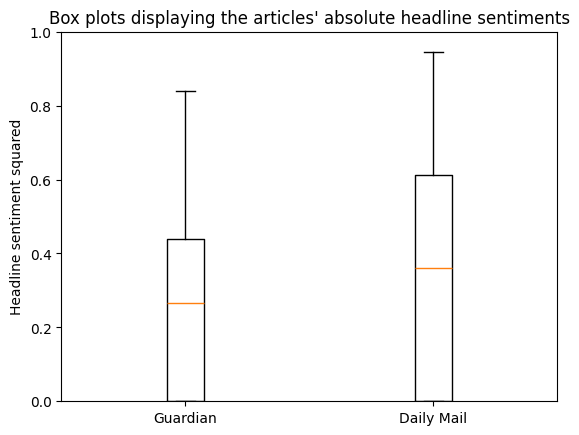

count    252.000000
mean       0.264948
std        0.245936
min        0.000000
25%        0.000000
50%        0.264950
75%        0.440400
max        0.840200
Name: headline_sentiment_squared, dtype: float64
count    208.000000
mean       0.342073
std        0.287735
min        0.000000
25%        0.000000
50%        0.359700
75%        0.611725
max        0.945800
Name: headline_sentiment_squared, dtype: float64
TtestResult(statistic=np.float64(-3.0992168883160196), pvalue=np.float64(0.0010299054731033506), df=np.float64(458.0))


In [140]:
# i'll use headline as proxy for article to gauge sentiment
# produce a histogram of df's headline_sentiment

# box plot of headline sentiment
# Create side-by-side box plots
fig, ax = plt.subplots()
ax.boxplot([df[df['paper'] == 'guardian']['headline_sentiment'], df[df['paper'] == 'dailymail']['headline_sentiment']], labels=['Guardian', 'Daily Mail'])

# Customize plot
ax.set_ylabel('Headline sentiment')
ax.set_title("Box plots displaying the articles' headline sentiments")
ax.set_ylim(-1, 1)

# Display plot

plt.show()

# display quartile range and median
print(df[df['paper'] == 'guardian']['headline_sentiment'].describe())
print(df[df['paper'] == 'dailymail']['headline_sentiment'].describe())
print(stats.ttest_ind(df[df['paper'] == 'guardian']['headline_sentiment'], df[df['paper'] == 'dailymail']['headline_sentiment'], alternative='less'))


# now do box plots for headline sentiment squared
df['headline_sentiment_squared'] = abs(df['headline_sentiment'])
fig, ax = plt.subplots()
ax.boxplot([df[df['paper'] == 'guardian']['headline_sentiment_squared'], df[df['paper'] == 'dailymail']['headline_sentiment_squared']], labels=['Guardian', 'Daily Mail'])

ax.set_ylabel('Absolute headline sentiment')
ax.set_title("Box plots displaying the articles' absolute headline sentiments")
ax.set_ylim(0, 1)

plt.show()

# describe both paper
print(df[df['paper'] == 'guardian']['headline_sentiment_squared'].describe())
print(df[df['paper'] == 'dailymail']['headline_sentiment_squared'].describe())

# is the difference between papers' sentiment significant?
# do one tail t-test
print(stats.ttest_ind(df[df['paper'] == 'guardian']['headline_sentiment_squared'], df[df['paper'] == 'dailymail']['headline_sentiment_squared'], alternative='less'))

# shows that uber headlines in the daily mail do tend to be more positive than the guardian

<ipython-input-184-4b701da1e1e5>:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_dm = df_dm.groupby(['published', 'quartile']).size().reset_index(name='count')
<ipython-input-184-4b701da1e1e5>:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_g = df_g.groupby(['published', 'quartile']).size().reset_index(name='count')


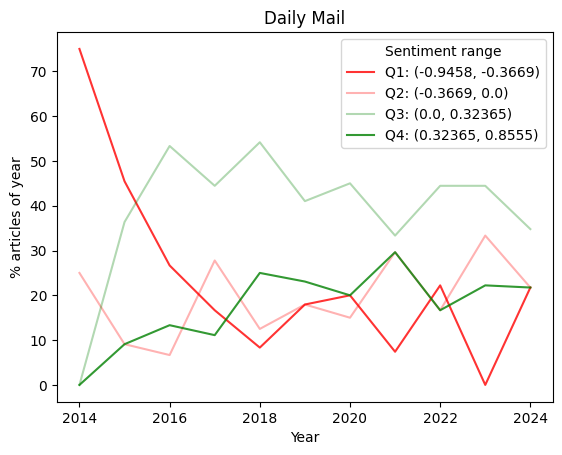

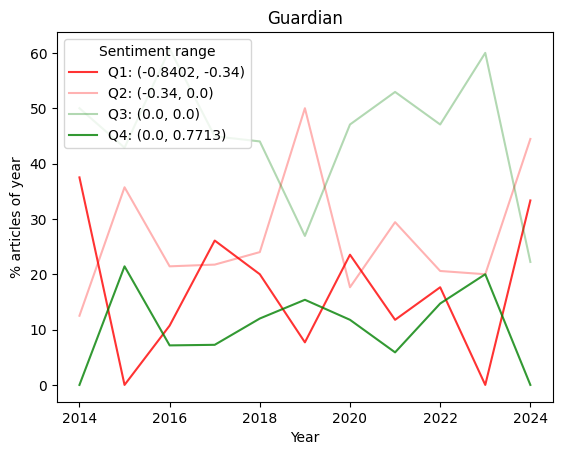

count_pct
                        corr         p
quartile paper                        
4        dailymail  0.723856  0.011786
1        dailymail -0.682577  0.020645
2        dailymail  0.406773    0.2144
3        dailymail  0.305282  0.361298
2        guardian   0.266135  0.428931
3        guardian   -0.23341  0.489729
1        guardian  -0.060848  0.858942
4        guardian   0.058655  0.863986
----
count
                        corr         p
quartile paper                        
2        dailymail  0.507183  0.111299
4        dailymail   0.43788  0.177984
3        dailymail  0.265016  0.430948
         guardian  -0.258632  0.442541
1        dailymail -0.161796  0.634585
         guardian  -0.146603  0.667098
2        guardian  -0.143019  0.674846
4        guardian  -0.133705  0.695112
----


In [184]:
# get min, 25% etc for each paper

df2 = df.copy()
#ignore 2014 articles
#df2 = df2[df2['published'] > 1420070399]

quartiles_df = df2.groupby('paper').describe()

# add quartile column which equals either 1,2,3 or 4
df_dm = df2.copy()[df2['paper'] == 'dailymail']
df_g = df2.copy()[df2['paper'] == 'guardian']
#quartile cut for each
dm_des = df_dm['headline_sentiment'].describe()
g_des = df_g['headline_sentiment'].describe()

df_dm['quartile'] = pd.cut(df_dm['headline_sentiment'], 4, labels=[1, 2, 3, 4])
df_g['quartile'] = pd.cut(df_g['headline_sentiment'], 4, labels=[1, 2, 3, 4])

# convert published timestamp to datetime
df_dm['published'] = df_dm['published'].apply(lambda x: datetime.fromtimestamp(x).year)
df_g['published'] = df_g['published'].apply(lambda x: datetime.fromtimestamp(x).year)

# for each quartile plot count against published
# group by year and quartile
df_dm = df_dm.groupby(['published', 'quartile']).size().reset_index(name='count')
df_g = df_g.groupby(['published', 'quartile']).size().reset_index(name='count')

# add sum column
df_dm['sum'] = df_dm.groupby('published')['count'].transform('sum')
df_g['sum'] = df_g.groupby('published')['count'].transform('sum')

# add count_pct column
df_dm['count_pct'] = df_dm['count'] / df_dm['sum'] * 100
df_g['count_pct'] = df_g['count'] / df_g['sum'] * 100

dm_des = [dm_des['min'], dm_des['25%'], dm_des['50%'], dm_des['75%'], dm_des['max']]
g_des = [g_des['min'], g_des['25%'], g_des['50%'], g_des['75%'], g_des['max']]

#plot df_dm as scatter between published and quartile count
for q in [1, 2, 3, 4]:
  a = 0.8 if q in [1,4] else 0.3
  c = 'red' if q in [1,2] else 'green'

  df_slice = df_dm[df_dm['quartile'] == q]
  label = f'Q{q}: ({dm_des[q-1]}, {dm_des[q]})'
  plt.plot(df_slice['published'], df_slice['count_pct'], label=label, alpha = a, color = c)
plt.legend(title = "Sentiment range")
plt.title('Daily Mail')
plt.xlabel('Year')
plt.ylabel('% articles of year')
plt.show()

for q in [1, 2, 3, 4]:
  a = 0.8 if q in [1,4] else 0.3
  c = 'red' if q in [1,2] else 'green'

  df_slice = df_g[df_g['quartile'] == q]
  label = f'Q{q}: ({g_des[q-1]}, {g_des[q]})'
  plt.plot(df_slice['published'], df_slice['count_pct'], label=label, alpha = a, color = c)

plt.legend(title = "Sentiment range")
plt.title('Guardian')
plt.xlabel('Year')
plt.ylabel('% articles of year')
plt.show()

# for each q see if there's a correlation between count_pct and published

# make a data frame for quartile, corr, p
for att in ['count_pct', 'count']:
  print(att)
  df_corr_pct = pd.DataFrame(columns=['quartile', 'paper', 'corr', 'p'])
  df_corr_pct.set_index(['quartile', 'paper'], inplace=True)

  for q in [1,2,3,4]:
    df_slice = df_dm[df_dm['quartile'] == q]
    c, p = stats.pearsonr(df_slice['published'], df_slice[att])
    df_corr_pct.at[(q, 'dailymail'), 'corr'] = c
    df_corr_pct.at[(q, 'dailymail'), 'p'] = p

  # do the same for guardian
  for q in [1,2,3,4]:
    df_slice = df_g[df_g['quartile'] == q]
    c, p = stats.pearsonr(df_slice['published'], df_slice[att])
    df_corr_pct.at[(q, 'guardian'), 'corr'] = c
    df_corr_pct.at[(q, 'guardian'), 'p'] = p

  # sort by p value ascending
  df_corr_pct.sort_values(by=['p'], ascending=True, inplace=True)
  print(df_corr_pct.head(10))
  print("----")

  # No relationship between sentiment and time








Correlation coefficients and p values (< 0.05)
mean: 0.13866614162665528 0.6842948108128253  False
mean: 0.629061214655452 0.038126345138092314  True
median: -0.2003576902070301 0.5547237281971034  False
median: 0.6135143011871081 0.04469333201774192  True


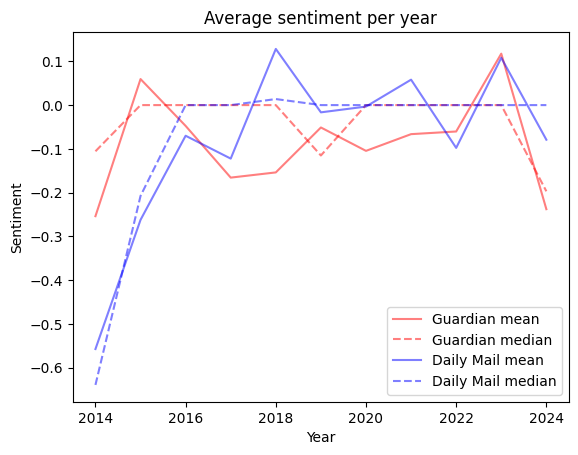

In [171]:
# plot average sentiment per year against published for each paper
df_dm = df.copy()[df['paper'] == 'dailymail']
df_g = df.copy()[df['paper'] == 'guardian']

# group by year of published
df_dm['published'] = df_dm['published'].apply(lambda x: datetime.fromtimestamp(x).year)
df_g['published'] = df_g['published'].apply(lambda x: datetime.fromtimestamp(x).year)

# group by published
df_dm.head(5)
df_dm = df_dm[["published", "headline_sentiment"]]
df_g = df_g[["published", "headline_sentiment"]]


# group by year and store mean and median
df_dm = df_dm.groupby('published').agg(['mean', 'median'])
df_g = df_g.groupby('published').agg(['mean', 'median'])

# remove pre 2016 entries
df_dm = df_dm[df_dm.index >= 2014]
df_g = df_g[df_g.index >= 2014]

# plot
plt.plot(df_g['headline_sentiment']['mean'], label='Guardian mean', color="red", alpha = 0.5)
plt.plot(df_g['headline_sentiment']['median'], label='Guardian median', linestyle='--', color="red", alpha = 0.5)
plt.plot(df_dm['headline_sentiment']['mean'], label='Daily Mail mean', color="blue", alpha = 0.5)
plt.plot(df_dm['headline_sentiment']['median'], label='Daily Mail median', linestyle= "--", color="blue", alpha = 0.5)

# get correlation coefficients and p-values for each variable
print("Correlation coefficients and p values (< 0.05)")
for att in ['mean', 'median']:
  for d in [df_g, df_dm]:
    c, p = stats.pearsonr(d['headline_sentiment'][att], d.index)
    print(att + ": " + str(c) + " " + str(p) + "  " + str(p < 0.05))

plt.ylabel('Sentiment')
plt.xlabel('Year')
plt.title('Average sentiment per year')

plt.legend()
plt.show()

In [ ]:
# in this block we're gonna use dfs from last block to test statistical significance


# add total words - sum column
"""df_matched['other'] = df_matched['bodies'].apply(str.split).apply(len) - df_matched['sum']
"""

df_overall.head(10)

# do chi square test
expected = df_overall['daily mail expected'].values
observed = df_overall['guardian'].values
chi2, p, dof, expected = stats.chi2_contingency([observed, expected])

print("Chi-squared statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)
print("Expected frequencies:\n", expected)


Chi-squared statistic: 79.23519935350201
p-value: 1.9724308842462727e-14
Degrees of freedom: 7
Expected frequencies:
 [[3.48395945e+02 4.22652670e+01 4.73118863e+01 1.20915303e+02
  2.05101780e+01 1.65081424e+02 2.66195019e+01 2.04096900e+05]
 [3.48395945e+02 4.22652670e+01 4.73118863e+01 1.20915303e+02
  2.05101780e+01 1.65081424e+02 2.66195019e+01 2.04096900e+05]]


In [ ]:
# This block will just display how many articles from each paper
# And combined length of all articles from each paper
df = load_articles('./final_data.json')
# Count all where paper = daily mail and guardian
df_count = df['paper'].value_counts().reset_index()
df_count.columns = ['paper', 'count']
df_count = df_count.set_index('paper')
# Load dataframe

# combined length
# append all bodies of each paper
df_count['bodies_size'] = df.groupby('paper')['body'].apply(lambda x: len(' '.join(x).split()))

"""# create a pie chart of each paper's count
df_count.plot.pie(y='count', figsize=(5, 5), autopct='%1.1f%%', ylabel='Number of articles', legend=False)
df_count

# create a pie chart of bodies size
df_count.plot.pie(y='bodies_size', figsize=(5, 5), autopct='%1.1f%%', ylabel='Number of words total', legend=False)"""
# add sum row
df_count.loc['total'] = df_count.sum()

# convert total articles to str
df_count['total articles'] = df_count['count'].apply(lambda x : str(x) + " (" + str(round(100 * x / df_count.loc['total']['count'])) + "%)")
df_count['total words'] = df_count['bodies_size'].apply(lambda x : str(x) + " (" + str(round(100 * x / df_count.loc['total']['bodies_size'])) + "%)")

df_count[['total articles', 'total words']].head(5)

,total articles,total words
paper,,
guardian,252 (55%),204877 (52%)
dailymail,208 (45%),190958 (48%)
total,460 (100%),395835 (100%)


In [ ]:
# load final_data as json and remove 2025
with open("./final_data.json", encoding='utf-8') as f:
    articles_raw = json.load(f)

  # Format df

articles = []
for paper in ['guardian', 'dailymail']:
    for a in articles_raw[paper]:
        a['paper'] = paper
        # ignore 2025 articles
        if a['published'] < 1735689600:
          articles.append(a)

# dump into new file
with open('./final_data2.json', 'w') as f:
    json.dump(articles, f)